Got it — you want the **Markdown documentation**, but without explaining what each method is. Just the method names.

## BEIR benchmark: simlar vs dense baselines

This notebook reproduces the BEIR results and compares `simlar` with three standard dense-vector baselines.

| Method |
| --- |
| `simlar` |
| `bruteforce` |
| `faiss` |
| `turbovec` |

### Reproducing

Run it top to bottom:

1. **Setup** installs anything that's missing (`simlar`, `sentence-transformers`, `faiss-cpu`, `turbovec`, `pandas`, `pytrec-eval-terrier`).
2. Datasets are **downloaded** from the UKP BEIR mirror into `DATA_DIR` if they aren't already there.
3. Embeddings are **generated** with `MODEL` and cached as `.npy` in `EMB_CACHE_DIR`. Later runs load the cache.
4. Results are written to `OUT_DIR` as JSON and CSV.

`DATASETS` defaults to the **full public BEIR suite** (14 datasets + the 12 CQADupStack forums; MSMARCO on `dev`).

Metrics: nDCG / Recall / P at `K_VALUES`, plus MAP and MRR, computed with **`pytrec_eval`**.

## 1. Setup: install missing dependencies

In [ ]:
%pip install simlar simlar-engine sentence-transformers faiss-cpu turbovec pandas numpy matplotlib pytrec-eval-terrier

[setup] all required packages present


## 2. Configuration
All paths are relative to the notebook. Set `BEIR_EMB_CACHE` to reuse an existing embedding cache.

In [ ]:
# ── datasets ──────────────────────────────────────────────────────────────────
# The full public BEIR suite (auto-downloaded on first use), smallest first. CQADupStack is
# 12 StackExchange forums benchmarked separately; the summary also reports their average,
# which is the single "cqadupstack" number BEIR papers quote.
CQADUPSTACK = ["android", "english", "gaming", "gis", "mathematica", "physics",
               "programmers", "stats", "tex", "unix", "webmasters", "wordpress"]
DATASETS = [
    "scifact", "nfcorpus", "arguana", "scidocs", "fiqa", "trec-covid", "webis-touche2020",
    *[f"cqadupstack/{f}" for f in CQADUPSTACK],
    "quora", "nq", "hotpotqa", "dbpedia-entity", "fever", "climate-fever", "msmarco",
]
SPLIT         = "test"
SPLITS        = {"msmarco": "dev"}   # per-dataset override (msmarco has no public test qrels)
LIMIT_QUERIES = 0                    # 0 = all queries; >0 for quick smoke tests
RESUME        = True                 # reuse OUT_DIR/<dataset>.json from a previous (partial) sweep

# ── paths (created if missing) ───────────────────────────────────────────────
DATA_DIR      = os.environ.get("BEIR_DATA_DIR",  "../beir_datasets")
EMB_CACHE_DIR = os.environ.get("BEIR_EMB_CACHE", "../beir_embeddings")
OUT_DIR       = os.environ.get("BEIR_OUT_DIR",   "./results_notebook")

# ── embeddings ───────────────────────────────────────────────────────────────
MODEL          = "WhereIsAI/UAE-Large-V1"
BATCH_SIZE     = 128
ENCODE_CHUNK   = 100_000         # texts encoded per chunk (caps peak RAM on huge corpora)
FORCE_REENCODE = False           # True = ignore the cache and regenerate embeddings

# ── retrieval ────────────────────────────────────────────────────────────────
METHODS       = ["simlar", "faiss", "bruteforce", "turbovec"]
TOP_K         = 1000
K_VALUES      = [1, 3, 5, 10, 100, 1000]
TURBOVEC_BITS = 4

# ── report ───────────────────────────────────────────────────────────────────
REPORT_K = 100                   # cutoff shown in the report tables/charts (NDCG/Recall/P@REPORT_K)
THEME    = "dark"                # "dark" | "light" for the report tables and charts

# ── reproducibility ──────────────────────────────────────────────────────────
N_THREADS = os.cpu_count()
SEED      = 0

K_VALUES = sorted({k for k in K_VALUES if k <= TOP_K} | {REPORT_K})
PLOT_DIR = os.path.join(OUT_DIR, "plots")
for d in (DATA_DIR, EMB_CACHE_DIR, OUT_DIR, PLOT_DIR):
    os.makedirs(d, exist_ok=True)
print(f"data={os.path.abspath(DATA_DIR)}\nemb_cache={os.path.abspath(EMB_CACHE_DIR)}\nout={os.path.abspath(OUT_DIR)}")

## 3. Imports, threads and seeds
Thread counts are pinned *before* the native libraries load, so every method gets the same number of cores.

In [16]:
for var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
            "RAYON_NUM_THREADS", "NUMBA_NUM_THREADS"):
    os.environ[var] = str(N_THREADS)

import faulthandler, gc, hashlib, json, math, platform, random, time, urllib.request, zipfile
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import faiss
import pytrec_eval
from turbovec import TurboQuantIndex
from simlar import HelixIndex, ReciprocalRankFusion

faulthandler.enable(all_threads=True)    # native crash -> Python traceback in the kernel log
faiss.omp_set_num_threads(N_THREADS)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def _version(mod):
    try:
        return importlib.metadata.version(mod)
    except Exception:
        return "unknown"

ENV = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch_device": "cuda:" + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "threads": N_THREADS,
    **{p: _version(p) for p in ("simlar", "simlar-engine", "sentence-transformers", "torch",
                                "faiss-cpu", "turbovec", "numpy", "pandas", "pytrec-eval-terrier")},
}
pd.Series(ENV, name="environment").to_frame()

,environment
python,3.13.16
platform,Linux-7.0.0-34-generic-x86_64-with-glibc2.43
torch_device,cuda:NVIDIA GeForce RTX 4090
threads,24
simlar,1.2.0
simlar-engine,1.1.0
sentence-transformers,6.1.0
torch,2.14.1
faiss-cpu,1.15.1
turbovec,1.1.2


## 4. Dataset loading
Downloads a BEIR dataset if `DATA_DIR/<name>/corpus.jsonl` isn't there yet, then reads corpus, queries and qrels.

In [17]:
Corpus  = Dict[str, Dict[str, str]]     # doc_id -> {"title", "text"}
Queries = Dict[str, str]                # query_id -> text
Qrels   = Dict[str, Dict[str, int]]     # query_id -> {doc_id: relevance}
Results = Dict[str, Dict[str, float]]   # query_id -> {doc_id: score}

BEIR_URL = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{name}.zip"


def resolve_dataset(dataset: str, data_dir: str) -> str:
    """Local path to a BEIR-format dataset dir, downloading + extracting if needed."""
    if os.path.isdir(dataset) and os.path.isfile(os.path.join(dataset, "corpus.jsonl")):
        return dataset
    target = os.path.join(data_dir, dataset)
    if os.path.isfile(os.path.join(target, "corpus.jsonl")):
        return target

    # cqadupstack/<forum>: the zip holds all 12 forums under cqadupstack/
    archive = dataset.split("/")[0]
    url = BEIR_URL.format(name=archive)
    zip_path = os.path.join(data_dir, f"{archive}.zip")
    print(f"[data] downloading {url}")
    _download(url, zip_path)
    print(f"[data] extracting into {data_dir}")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_dir)
    os.remove(zip_path)
    if not os.path.isfile(os.path.join(target, "corpus.jsonl")):
        raise FileNotFoundError(f"Extracted {archive} but no corpus.jsonl under {target!r}")
    return target


def _download(url: str, dest: str) -> None:
    def _hook(count, block, total):
        if total > 0:
            sys.stdout.write(f"\r[data]   {min(100, count * block * 100 // total):3d}%")
            sys.stdout.flush()
    try:
        urllib.request.urlretrieve(url, dest, _hook)
    finally:
        sys.stdout.write("\r")


def load_beir(path: str, split: str) -> Tuple[Corpus, Queries, Qrels]:
    corpus: Corpus = {}
    with open(os.path.join(path, "corpus.jsonl"), encoding="utf-8") as fh:
        for line in fh:
            d = json.loads(line)
            corpus[d["_id"]] = {"title": d.get("title", ""), "text": d.get("text", "")}

    all_queries: Queries = {}
    with open(os.path.join(path, "queries.jsonl"), encoding="utf-8") as fh:
        for line in fh:
            d = json.loads(line)
            all_queries[d["_id"]] = d.get("text", "")

    qrels_path = os.path.join(path, "qrels", f"{split}.tsv")
    if not os.path.isfile(qrels_path):
        qdir = os.path.join(path, "qrels")
        avail = [f[:-4] for f in os.listdir(qdir) if f.endswith(".tsv")] if os.path.isdir(qdir) else []
        raise FileNotFoundError(f"No qrels for split {split!r} at {qrels_path}. Available: {avail}")

    qrels: Qrels = {}
    with open(qrels_path, encoding="utf-8") as fh:
        fh.readline()  # header
        for line in fh:
            parts = line.strip().split("\t")
            if len(parts) >= 3:
                qrels.setdefault(parts[0], {})[parts[1]] = int(parts[2])

    # Keep only queries judged in this split.
    queries = {qid: all_queries[qid] for qid in qrels if qid in all_queries}
    return corpus, queries, qrels


def doc_text(doc: Dict[str, str]) -> str:
    title, text = doc.get("title", ""), doc.get("text", "")
    return f"{title} {text}".strip() if title else text

## 5. Embeddings: generate or load from cache
Embeddings are normalized float32 vectors, so inner product = cosine. They are encoded in chunks that stream
straight into a memmap-backed `.npy` file, so even multi-million-doc corpora never hold the full matrix in RAM.
The cache filename includes a content fingerprint, so a changed corpus or query set is re-encoded instead of
loading stale vectors.

In [18]:
_MODELS = {}

os.environ["TOKENIZERS_PARALLELISM"] = "false"  # avoid a warning from sentence-transformers
def _emb_cache_path(cache_dir, dataset, model_name, label, texts) -> str:
    n = len(texts)
    h = hashlib.sha1()
    h.update(f"{n}|{sum(len(t) for t in texts)}".encode())
    for idx in (0, n // 2, n - 1):
        if 0 <= idx < n:
            h.update(texts[idx].encode("utf-8", "ignore"))
            h.update(b"\x00")
    safe_model = model_name.replace("/", "_").replace(" ", "_")
    safe_ds = os.path.basename(os.path.normpath(dataset)) or "dataset"
    return os.path.join(cache_dir, f"{safe_ds}__{safe_model}__{label}__{n}__{h.hexdigest()[:12]}.npy")


def encode(texts: List[str], label: str, dataset: str) -> np.ndarray:
    """Normalized float32 embeddings for `texts`, from cache if present, else generated + cached."""
    cache_path = _emb_cache_path(EMB_CACHE_DIR, dataset, MODEL, label, texts)
    if os.path.isfile(cache_path) and not FORCE_REENCODE:
        arr = np.load(cache_path, mmap_mode="r")
        print(f"[embed] {label}: loaded {arr.shape} from cache {cache_path}")
        return arr

    from sentence_transformers import SentenceTransformer
    if MODEL not in _MODELS:
        print(f"[embed] loading model {MODEL}")
        _MODELS[MODEL] = SentenceTransformer(MODEL)
    model = _MODELS[MODEL]

    n = len(texts)
    print(f"[embed] {label}: cache miss -> generating {n} embeddings (batch={BATCH_SIZE}, device={model.device})")
    t0 = time.perf_counter()

    def _chunk(ts):
        return np.ascontiguousarray(model.encode(
            ts, batch_size=BATCH_SIZE, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True), dtype=np.float32)

    first = _chunk(texts[:ENCODE_CHUNK])
    dim = first.shape[1]
    tmp = cache_path + ".tmp"
    out = np.lib.format.open_memmap(tmp, mode="w+", dtype=np.float32, shape=(n, dim))
    out[:len(first)] = first
    for start in range(ENCODE_CHUNK, n, ENCODE_CHUNK):
        out[start:start + ENCODE_CHUNK] = _chunk(texts[start:start + ENCODE_CHUNK])
        sys.stdout.write(f"\r[embed]   {min(start + ENCODE_CHUNK, n)}/{n}")
        sys.stdout.flush()
    out.flush()
    del out
    os.replace(tmp, cache_path)   # atomic: an interrupted run never leaves a truncated cache
    print(f"\n[embed] {label}: generated ({n}, {dim}) in {time.perf_counter() - t0:.1f}s -> {cache_path}")
    return np.load(cache_path, mmap_mode="r")

## 6. Evaluation
Official trec_eval measures via `pytrec_eval`: `ndcg_cut`, `recall` and `P` at every cutoff in `K_VALUES`, plus `map` and `recip_rank` (MRR), averaged over the judged queries.

In [19]:
def evaluate(qrels: Qrels, results: Results, k_values: List[int]) -> Dict[str, float]:
    measures = {
        "ndcg_cut." + ",".join(map(str, k_values)),
        "recall." + ",".join(map(str, k_values)),
        "P." + ",".join(map(str, k_values)),
        "map",
        "recip_rank",
    }
    per_query = pytrec_eval.RelevanceEvaluator(qrels, measures).evaluate(results)
    n = len(per_query)
    mean = lambda key: sum(q.get(key, 0.0) for q in per_query.values()) / n if n else 0.0

    out: Dict[str, float] = {}
    for k in k_values:
        out[f"NDCG@{k}"] = mean(f"ndcg_cut_{k}")
        out[f"Recall@{k}"] = mean(f"recall_{k}")
        out[f"P@{k}"] = mean(f"P_{k}")
    out["MAP"] = mean("map")
    out["MRR"] = mean("recip_rank")
    return out

## 7. Retrievers
Every retriever has the same interface: `build(...)`, `warmup(...)` (a throwaway 1-query search so JIT/first-call
costs stay out of the timed region) and `search(...) -> Results`.

In [20]:
def positions_to_results(q_ids, doc_ids, scores, positions) -> Results:
    """(Q, k) score/position matrices -> {qid: {doc_id: score}}; -1 = empty slot."""
    out: Results = {}
    for qid, srow, prow in zip(q_ids, scores, positions):
        out[qid] = {doc_ids[p]: float(s) for s, p in zip(srow, prow) if p >= 0}
    return out


class Simlar:
    """simlar HelixIndex (default text + vector indexes): BM25 + binary-quantized dense, RRF-fused."""
    name = "simlar"

    def build(self, corpus, doc_ids, doc_emb):
        self.index = HelixIndex(
            fusion=ReciprocalRankFusion(k=60, weights=[0.5, 1.0]),
            top_k=TOP_K,
        )
        self.index.add(ids=doc_ids, texts=[doc_text(corpus[d]) for d in doc_ids], vectors=doc_emb)

    def warmup(self, q_texts, q_emb):
        self.index.search(query_text=q_texts[:1], query_vector=q_emb[:1], k=1, parallel=True)

    def search(self, q_ids, q_texts, q_emb, k) -> Results:
        hits = self.index.search(query_text=q_texts, query_vector=q_emb, k=k, parallel=True)
        return {qid: {h.id: float(h.score) for h in hs} for qid, hs in zip(q_ids, hits)}


class DenseBaseline:
    """Shared plumbing for vector-only baselines: subclasses implement _build/_search."""
    def build(self, corpus, doc_ids, doc_emb):
        self.doc_ids = doc_ids
        self._build(doc_emb)

    def warmup(self, q_texts, q_emb):
        self._search(np.ascontiguousarray(q_emb[:1]), 1)

    def search(self, q_ids, q_texts, q_emb, k) -> Results:
        scores, positions = self._search(np.ascontiguousarray(q_emb), min(k, len(self.doc_ids)))
        return positions_to_results(q_ids, self.doc_ids, np.asarray(scores), np.asarray(positions))


class BruteForce(DenseBaseline):
    """Exact float32 inner product in NumPy, over corpus chunks with a running top-k merge,
    so neither the full corpus nor a full (Q x N) score matrix needs to be in RAM."""
    name = "bruteforce"
    Q_BATCH, D_CHUNK = 1024, 100_000

    def _build(self, doc_emb):
        self.emb = doc_emb            # no index: keep a (memmapped) reference

    def _search(self, q, k):
        # Corpus chunks are the outer loop so each chunk is read from the memmap exactly once
        # (msmarco's corpus is ~36 GB); every query keeps a running top-k across chunks.
        n = self.emb.shape[0]
        best_s = np.full((len(q), 0), -np.inf, np.float32)
        best_p = np.empty((len(q), 0), np.int64)
        for ds in range(0, n, self.D_CHUNK):
            chunk = np.ascontiguousarray(self.emb[ds:ds + self.D_CHUNK], dtype=np.float32)
            new_s, new_p = [], []
            for qs in range(0, len(q), self.Q_BATCH):
                s = np.concatenate([best_s[qs:qs + self.Q_BATCH], q[qs:qs + self.Q_BATCH] @ chunk.T], axis=1)
                p = np.concatenate([best_p[qs:qs + self.Q_BATCH],
                                    np.broadcast_to(np.arange(ds, ds + len(chunk)), (len(s), len(chunk)))], axis=1)
                if s.shape[1] > k:
                    keep = np.argpartition(-s, k - 1, axis=1)[:, :k]
                    s, p = np.take_along_axis(s, keep, 1), np.take_along_axis(p, keep, 1)
                new_s.append(s)
                new_p.append(p)
            best_s, best_p = np.concatenate(new_s), np.concatenate(new_p)
        order = np.argsort(-best_s, axis=1, kind="stable")
        return np.take_along_axis(best_s, order, 1), np.take_along_axis(best_p, order, 1)


class Faiss(DenseBaseline):
    """FAISS IndexFlatIP: exhaustive exact inner product with BLAS kernels."""
    name = "faiss"

    def _build(self, doc_emb):
        self.index = faiss.IndexFlatIP(doc_emb.shape[1])
        for s in range(0, doc_emb.shape[0], 1_000_000):      # chunked add keeps memmap reads bounded
            self.index.add(np.ascontiguousarray(doc_emb[s:s + 1_000_000], dtype=np.float32))

    def _search(self, q, k):
        return self.index.search(q, k)


class TurboVec(DenseBaseline):
    """turbovec TurboQuantIndex: TURBOVEC_BITS-bit quantized vectors."""
    name = "turbovec"

    def _build(self, doc_emb):
        self.index = TurboQuantIndex(dim=doc_emb.shape[1], bit_width=TURBOVEC_BITS)
        for s in range(0, doc_emb.shape[0], 1_000_000):
            self.index.add(np.ascontiguousarray(doc_emb[s:s + 1_000_000], dtype=np.float32))

    def _search(self, q, k):
        return self.index.search(q, k=k)


RETRIEVERS = {cls.name: cls for cls in (Simlar, BruteForce, Faiss, TurboVec)}
assert set(METHODS) <= set(RETRIEVERS), f"unknown methods: {set(METHODS) - set(RETRIEVERS)}"

## 8. Benchmark one dataset
Queries and corpus are encoded once per dataset and shared by every method. Each method is timed separately for
**build** and **search** (after warmup), then evaluated.

In [21]:
def run_dataset(dataset: str) -> dict:
    print(f"\n{'█' * 60}\n█ {dataset}\n{'█' * 60}")
    path = resolve_dataset(dataset, DATA_DIR)
    split = SPLITS.get(dataset, SPLIT)
    corpus, queries, qrels = load_beir(path, split)
    if LIMIT_QUERIES and LIMIT_QUERIES < len(queries):
        keep = list(queries)[:LIMIT_QUERIES]
        queries = {q: queries[q] for q in keep}
        qrels = {q: qrels[q] for q in keep if q in qrels}
    print(f"[data] {len(corpus)} docs, {len(queries)} queries")

    doc_ids = list(corpus)
    q_ids = list(queries)
    q_texts = [queries[q] for q in q_ids]
    q_emb = np.ascontiguousarray(encode(q_texts, "query", dataset), dtype=np.float32)
    doc_emb = encode([doc_text(corpus[d]) for d in doc_ids], "corpus", dataset)

    runs: Dict[str, dict] = {}
    for method in METHODS:
        print(f"\n── {dataset} / {method} " + "─" * 30)
        r = RETRIEVERS[method]()
        t0 = time.perf_counter()
        r.build(corpus, doc_ids, doc_emb)
        build_s = time.perf_counter() - t0
        r.warmup(q_texts, q_emb)
        t0 = time.perf_counter()
        results = r.search(q_ids, q_texts, q_emb, TOP_K)
        search_s = time.perf_counter() - t0
        print(f"[{method}] build {build_s:.2f}s, search {search_s:.3f}s "
              f"({len(q_ids) / search_s:.0f} q/s)")
        runs[method] = {
            "metrics": evaluate(qrels, results, K_VALUES),
            "build_seconds": round(build_s, 3),
            "retrieval_seconds": round(search_s, 3),
            "qps": round(len(q_ids) / search_s, 1),
        }
        del r, results
        gc.collect()

    return {"dataset": dataset, "split": split, "num_docs": len(corpus),
            "num_queries": len(queries), "runs": runs}


def result_path(dataset: str) -> str:
    """OUT_DIR/<name>.json, e.g. scifact.json, cqadupstack-android.json."""
    return os.path.join(OUT_DIR, os.path.normpath(dataset).strip("./").replace("/", "-") + ".json")


def save_dataset(dataset: str, payload: dict) -> str:
    """Write one dataset's results (script's --output shape + config + environment)."""
    out = {
        "model": MODEL, "top_k": TOP_K,
        "turbovec_bits": TURBOVEC_BITS, "k_values": K_VALUES, "limit_queries": LIMIT_QUERIES,
        "environment": ENV, "datasets": {dataset: payload},
    }
    path = result_path(dataset)
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as fh:
        json.dump(out, fh, indent=2)
    os.replace(tmp, path)
    return path

## 9. Run
Each dataset's results are saved as soon as it finishes, so a crash later in the sweep keeps the finished ones. With `RESUME = True`, datasets that already have a results file (with every method in `METHODS`) are loaded instead of re-run, so an interrupted sweep continues where it stopped.

In [22]:
def load_saved(dataset: str):
    path = result_path(dataset)
    if not os.path.isfile(path):
        return None
    with open(path, encoding="utf-8") as fh:
        saved = json.load(fh)
    payload = next(iter(saved["datasets"].values()))
    same_run = (saved.get("model") == MODEL and saved.get("top_k") == TOP_K
                and saved.get("limit_queries", 0) == LIMIT_QUERIES)
    return payload if same_run and set(METHODS) <= set(payload["runs"]) else None


ALL: Dict[str, dict] = {}
for ds in DATASETS:
    if RESUME and (saved := load_saved(ds)) is not None:
        ALL[ds] = saved
        print(f"[resume] {ds}: loaded {result_path(ds)}")
        continue
    try:
        ALL[ds] = run_dataset(ds)
    except Exception as exc:          # keep going if one dataset fails
        print(f"[error] {ds}: {type(exc).__name__}: {exc}")
    else:
        print(f"[out] wrote {save_dataset(ds, ALL[ds])}")

[resume] scifact: loaded ./results_notebook/scifact.json
[resume] nfcorpus: loaded ./results_notebook/nfcorpus.json
[resume] arguana: loaded ./results_notebook/arguana.json

████████████████████████████████████████████████████████████
█ scidocs
████████████████████████████████████████████████████████████


[data] 25657 docs, 1000 queries
[embed] query: loaded (1000, 1024) from cache /home/aramirez/data/beir_embeddings/scidocs__WhereIsAI_UAE-Large-V1__query__1000__9bacf50d2da2.npy
[embed] corpus: loaded (25657, 1024) from cache /home/aramirez/data/beir_embeddings/scidocs__WhereIsAI_UAE-Large-V1__corpus__25657__99e6ce2fedcc.npy

── scidocs / simlar ──────────────────────────────
[simlar] build 2.59s, search 1.319s (758 q/s)

── scidocs / faiss ──────────────────────────────
[faiss] build 0.03s, search 0.198s (5054 q/s)

── scidocs / bruteforce ──────────────────────────────
[bruteforce] build 0.00s, search 0.444s (2253 q/s)

── scidocs / turbovec ──────────────────────────────
[turbovec] build 0.12s, search 0.380s (2629 q/s)
[out] wrote ./results_notebook/scidocs.json

████████████████████████████████████████████████████████████
█ fiqa
████████████████████████████████████████████████████████████
[data] 57638 docs, 648 queries
[embed] query: loaded (648, 1024) from cache /home/aramirez/data

## 10. Report style
Each engine keeps one color everywhere. The palette is the validated categorical default: a colorblind-safe
adjacent order, with the dark steps tuned for a dark surface. `simlar` is HelixIndex (hybrid BM25 + dense). `turbovec †` is
lossy (quantized), while faiss `IndexFlatIP` and brute force are exact.

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, PercentFormatter
from IPython.display import HTML, display

ENGINE_LABEL = {"simlar": "simlar", "faiss": "faiss", "bruteforce": "brute force", "turbovec": "turbovec †"}
CHART_ORDER = [m for m in ("bruteforce", "turbovec", "faiss", "simlar") if m in METHODS]  # simlar last = labeled bar
REPORT_METRICS = [f"NDCG@{REPORT_K}", f"Recall@{REPORT_K}", f"P@{REPORT_K}", "MAP", "MRR"]
PERCENT_METRICS = {f"NDCG@{REPORT_K}", f"Recall@{REPORT_K}", f"P@{REPORT_K}"}
FOOTNOTE = f"† approximate: {TURBOVEC_BITS}-bit quantized vectors. faiss (IndexFlatIP) and brute force are exact."
MONO = "DejaVu Sans Mono"

PALETTE = {   # categorical slots 1-4, validated (scripts/validate_palette.js) per mode
    "dark":  {"series": ["#3987e5", "#c98500", "#199e70", "#d95926"], "surface": "#141413",
              "card": "#1a1a19", "border": "#2e2e2b", "text": "#ffffff", "text2": "#c3c2b7",
              "muted": "#8a8984", "grid": "#2e2e2b"},
    "light": {"series": ["#2a78d6", "#eda100", "#1baf7a", "#eb6834"], "surface": "#fcfcfb",
              "card": "#ffffff", "border": "#e4e3df", "text": "#0b0b0b", "text2": "#52514e",
              "muted": "#7a7975", "grid": "#e4e3df"},
}[THEME]
ENGINE_COLOR = {m: PALETTE["series"][i] for i, m in enumerate(("bruteforce", "turbovec", "faiss", "simlar"))}


def fmt_metric(name: str, v: float) -> str:
    return f"{100 * v:.1f}%" if name in PERCENT_METRICS else f"{v:.3f}"


def report_frame(payload: dict) -> pd.DataFrame:
    """Engines x REPORT_METRICS, in METHODS order."""
    return pd.DataFrame({m: payload["runs"][m]["metrics"] for m in METHODS if m in payload["runs"]}
                        ).T.loc[:, REPORT_METRICS]


def report_table_html(df: pd.DataFrame, title: str = "", subtitle: str = "", first_col: str = "ENGINE",
                      row_labels=None) -> str:
    """Card-style table: one row per engine, metric columns."""
    p = PALETTE
    row_labels = row_labels or {}
    th = (f"text-align:left;padding:14px 24px;font:600 12px/1 ui-monospace,SFMono-Regular,Menlo,monospace;"
          f"letter-spacing:.08em;text-transform:uppercase;color:{p['muted']};border-bottom:1px solid {p['border']}")
    td = f"text-align:left;padding:14px 24px;font:15px/1.2 system-ui,sans-serif;color:{p['text']};border-top:1px solid {p['border']}"
    head = "".join(f"<th style='{th}'>{c}</th>" for c in [first_col, *df.columns])
    body = "".join(
        "<tr>" + f"<td style='{td}'>{row_labels.get(idx, idx)}</td>"
        + "".join(f"<td style='{td};font-variant-numeric:tabular-nums'>{'—' if pd.isna(v) else fmt_metric(c, v)}</td>"
                  for c, v in row.items()) + "</tr>"
        for idx, row in df.iterrows())
    cap = (f"<div style='font:600 15px ui-monospace,Menlo,monospace;color:{p['text']};margin:0 0 2px'>{title}</div>"
           f"<div style='font:13px system-ui,sans-serif;color:{p['text2']};margin:0 0 10px'>{subtitle}</div>") if title else ""
    return (f"<div style='background:{p['surface']};padding:16px;border-radius:12px;max-width:980px'>{cap}"
            f"<table style='width:100%;border-collapse:separate;border-spacing:0;background:{p['card']};"
            f"border:1px solid {p['border']};border-radius:10px;overflow:hidden'>"
            f"<thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"
            f"<div style='font:12px system-ui,sans-serif;color:{p['muted']};margin-top:8px'>{FOOTNOTE}</div></div>")


def metric_by_dataset(metric: str) -> pd.DataFrame:
    """Datasets x engines for one metric; the 12 CQADupStack forums fold into one averaged row."""
    df = pd.DataFrame({
        os.path.basename(result_path(ds))[:-5]: {m: run["metrics"].get(metric) for m, run in p["runs"].items()}
        for ds, p in ALL.items()
    }).T.reindex(columns=METHODS).astype(float)
    cqa = [i for i in df.index if i.startswith("cqadupstack-")]
    if cqa:
        df = pd.concat([df.drop(index=cqa), df.loc[cqa].mean().to_frame("cqadupstack (avg)").T])
    return df


def plot_metric_by_dataset(metric: str, save_to: str = ""):
    """Horizontal grouped bars: one group per dataset (sorted by simlar, best first), one thin
    rounded bar per engine in fixed colors; only simlar's bar carries a value label."""
    p = PALETTE
    df = metric_by_dataset(metric)
    sort_by = "simlar" if "simlar" in df else df.columns[0]
    df = df.sort_values(sort_by, ascending=False, na_position="last")
    is_pct = metric in PERCENT_METRICS
    xmax = 1.0 if is_pct and df.max().max() > 0.5 else float(np.nanmax(df.values)) * 1.08

    n, k = len(df), len(CHART_ORDER)
    row_h, bar_gap = 1.0, 0.18                       # dataset band, spacing between bars
    fig_h = 0.62 * n + 1.6
    fig, ax = plt.subplots(figsize=(11, fig_h), dpi=110)
    fig.patch.set_facecolor(p["card"])
    ax.set_facecolor(p["card"])
    lw = max(3.0, min(6.0, 72 * fig_h * 0.78 / (n * (k + 1.5)) * 0.55))   # bar thickness in points

    for r, (ds, row) in enumerate(df.iterrows()):
        for j, eng in enumerate(CHART_ORDER):
            y = r * row_h + (j - (k - 1) / 2) * bar_gap
            v = row.get(eng)
            if v is None or np.isnan(v):
                ax.text(xmax * 0.012, y, "no data", va="center", fontsize=8, color=p["muted"],
                        fontstyle="italic", family=MONO)
                continue
            ax.hlines(y, 0, v, color=ENGINE_COLOR[eng], linewidth=lw, capstyle="round")
            if eng == sort_by:                       # selective direct label: the engine being ranked
                ax.text(v + xmax * 0.012, y, fmt_metric(metric, v), va="center", fontsize=9.5,
                        color=p["text"], fontweight="bold", family=MONO)

    ax.set_yticks(np.arange(n) * row_h, df.index)
    ax.invert_yaxis()
    ax.set_ylim(n * row_h - 0.4, -0.6)
    ax.set_xlim(0, xmax * 1.1)
    ticks = np.linspace(0, xmax, 5)
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    if is_pct:
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    else:
        ax.set_xticklabels([f"{t:.2f}" for t in ticks])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", colors=p["text2"], labelsize=11, length=0, pad=10)
    ax.tick_params(axis="x", colors=p["muted"], labelsize=9, length=0, pad=8)
    for t in ax.get_xticklabels():
        t.set_family(MONO)
    ax.grid(axis="x", color=p["grid"], linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_title(f"{metric} by dataset", loc="left", color=p["text"], fontsize=13, family=MONO, pad=14)

    handles = [plt.Rectangle((0, 0), 1, 1, color=ENGINE_COLOR[e]) for e in CHART_ORDER]
    leg = fig.legend(handles, [ENGINE_LABEL[e] for e in CHART_ORDER], ncols=k, loc="lower left",
                     bbox_to_anchor=(0.02, 0.0), frameon=False, handlelength=1, handleheight=1,
                     prop={"family": MONO, "size": 10})
    for t in leg.get_texts():
        t.set_color(p["text2"])                      # text wears text ink, not the series color
    fig.tight_layout(rect=(0, 0.6 / fig_h, 1, 1))
    fig.add_artist(plt.Line2D([0.02, 0.98], [0.62 / fig_h, 0.62 / fig_h], color=p["border"], linewidth=1))
    if save_to:
        fig.savefig(save_to, facecolor=p["card"], bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 11. Per-dataset results
One engine table per dataset: NDCG / Recall / P at `REPORT_K`, MAP and MRR.

In [24]:
for ds, payload in ALL.items():
    display(HTML(report_table_html(
        report_frame(payload), title=os.path.basename(result_path(ds))[:-5], row_labels=ENGINE_LABEL,
        subtitle=f"{payload['split']} split · {payload['num_docs']:,} docs · {payload['num_queries']:,} queries")))

ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,78.1%,98.2%,1.1%,0.720,0.730
faiss,76.4%,96.5%,1.1%,0.703,0.712
brute force,76.4%,96.5%,1.1%,0.703,0.712
turbovec †,76.7%,96.8%,1.1%,0.707,0.715


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,36.0%,37.1%,9.2%,0.206,0.601
faiss,35.6%,36.7%,9.0%,0.207,0.580
brute force,35.6%,36.7%,9.0%,0.207,0.580
turbovec †,35.5%,36.6%,8.9%,0.207,0.578


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,48.9%,99.3%,1.0%,0.332,0.332
faiss,49.4%,99.1%,1.0%,0.337,0.337
brute force,49.4%,99.1%,1.0%,0.337,0.337
turbovec †,49.3%,99.1%,1.0%,0.337,0.337


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,32.7%,53.9%,2.7%,0.167,0.384
faiss,32.2%,53.2%,2.6%,0.164,0.374
brute force,32.2%,53.2%,2.6%,0.164,0.374
turbovec †,32.2%,53.2%,2.6%,0.164,0.375


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,48.2%,75.4%,1.9%,0.347,0.489
faiss,51.2%,75.9%,1.9%,0.383,0.541
brute force,51.2%,75.9%,1.9%,0.383,0.541
turbovec †,51.2%,76.3%,1.9%,0.382,0.540


...

ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,76.2%,90.0%,1.8%,0.650,0.865
faiss,76.3%,88.6%,1.8%,0.662,0.861
brute force,76.3%,88.6%,1.8%,0.662,0.861
turbovec †,76.2%,88.6%,1.8%,0.661,0.860


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,49.6%,61.6%,12.6%,0.329,0.731
faiss,48.8%,57.0%,11.4%,0.317,0.779
brute force,48.8%,57.0%,11.4%,0.317,0.779
turbovec †,48.8%,57.0%,11.4%,0.317,0.781


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,75.4%,96.4%,1.1%,0.679,0.713
faiss,84.2%,95.9%,1.1%,0.792,0.834
brute force,84.2%,95.9%,1.1%,0.792,0.834
turbovec †,84.2%,95.9%,1.1%,0.792,0.834


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,35.4%,62.1%,1.8%,0.210,0.363
faiss,37.5%,62.6%,1.8%,0.235,0.401
brute force,37.5%,62.6%,1.8%,0.235,0.401
turbovec †,37.5%,62.5%,1.8%,0.236,0.402


ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,43.7%,88.4%,0.9%,0.317,0.322
faiss,47.1%,88.7%,0.9%,0.358,0.364
brute force,47.1%,88.7%,0.9%,0.358,0.364
turbovec †,47.1%,88.7%,0.9%,0.358,0.363


## 12. Charts: each metric across all BEIR datasets
One chart per report metric. Datasets are sorted by simlar's score, and simlar's value is labeled. The 12
CQADupStack forums are shown as one averaged row, as in the BEIR paper. Charts are also saved to `OUT_DIR/plots/`,
and each metric's dataset × engine table goes to `OUT_DIR/summary_<metric>.csv`.

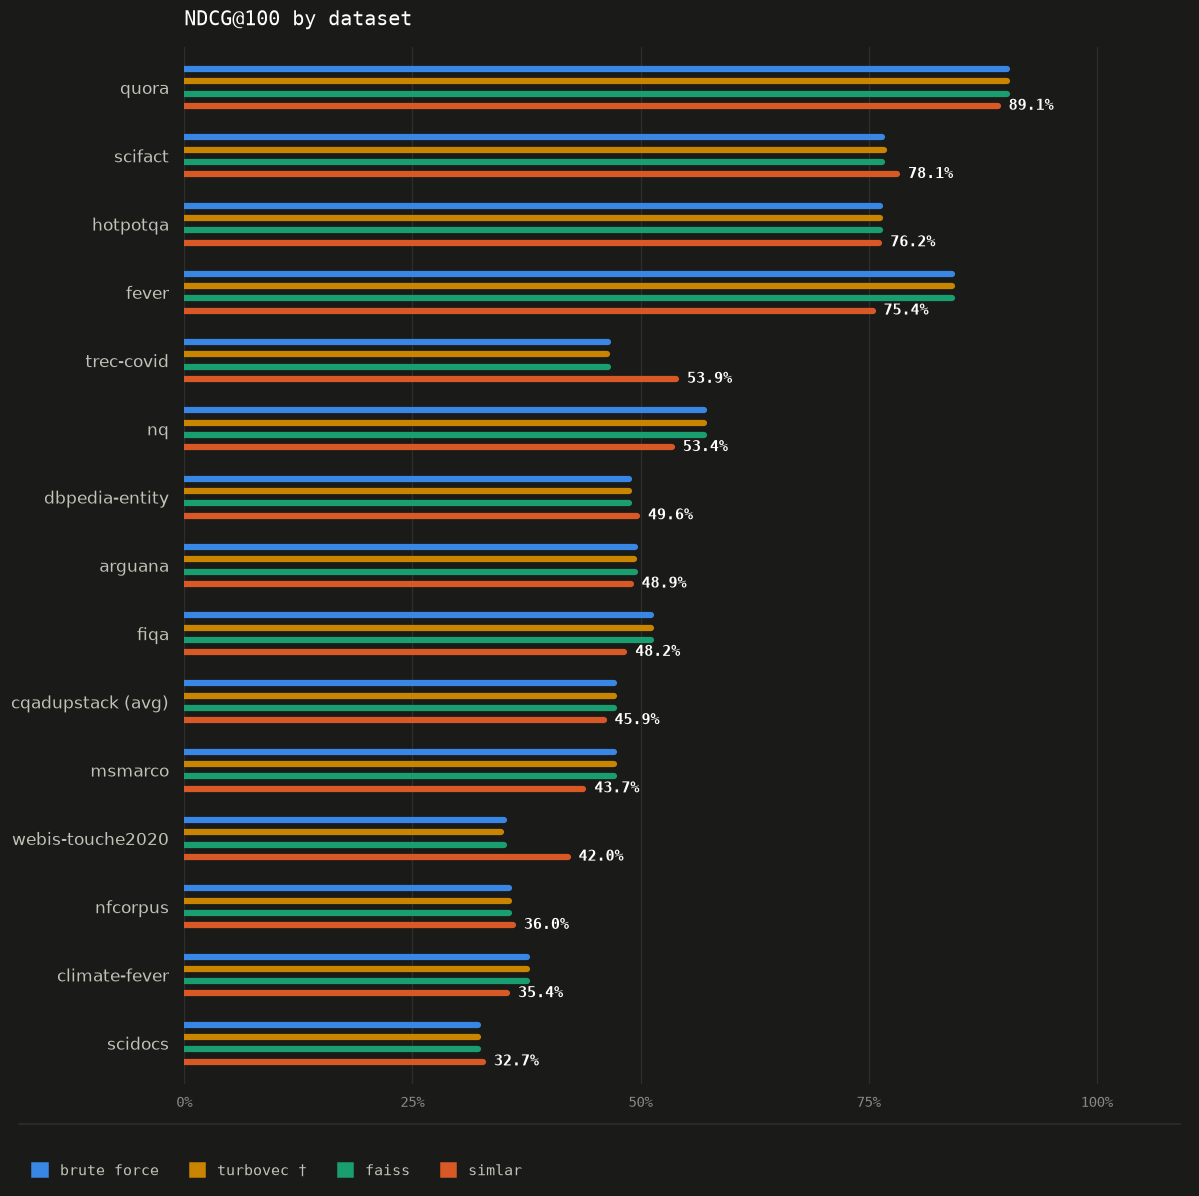

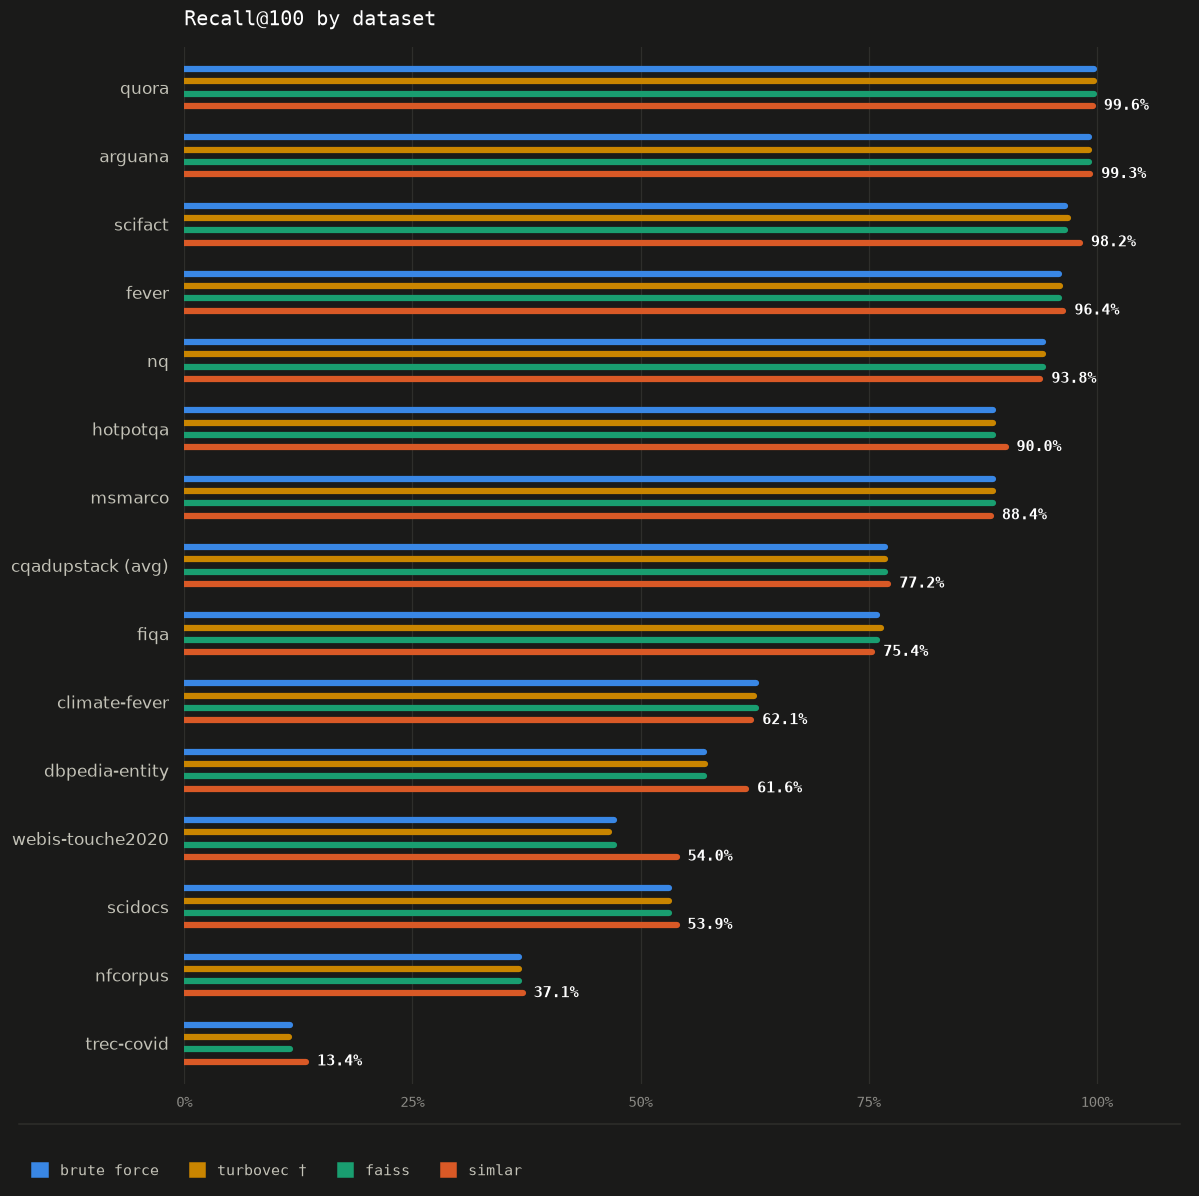

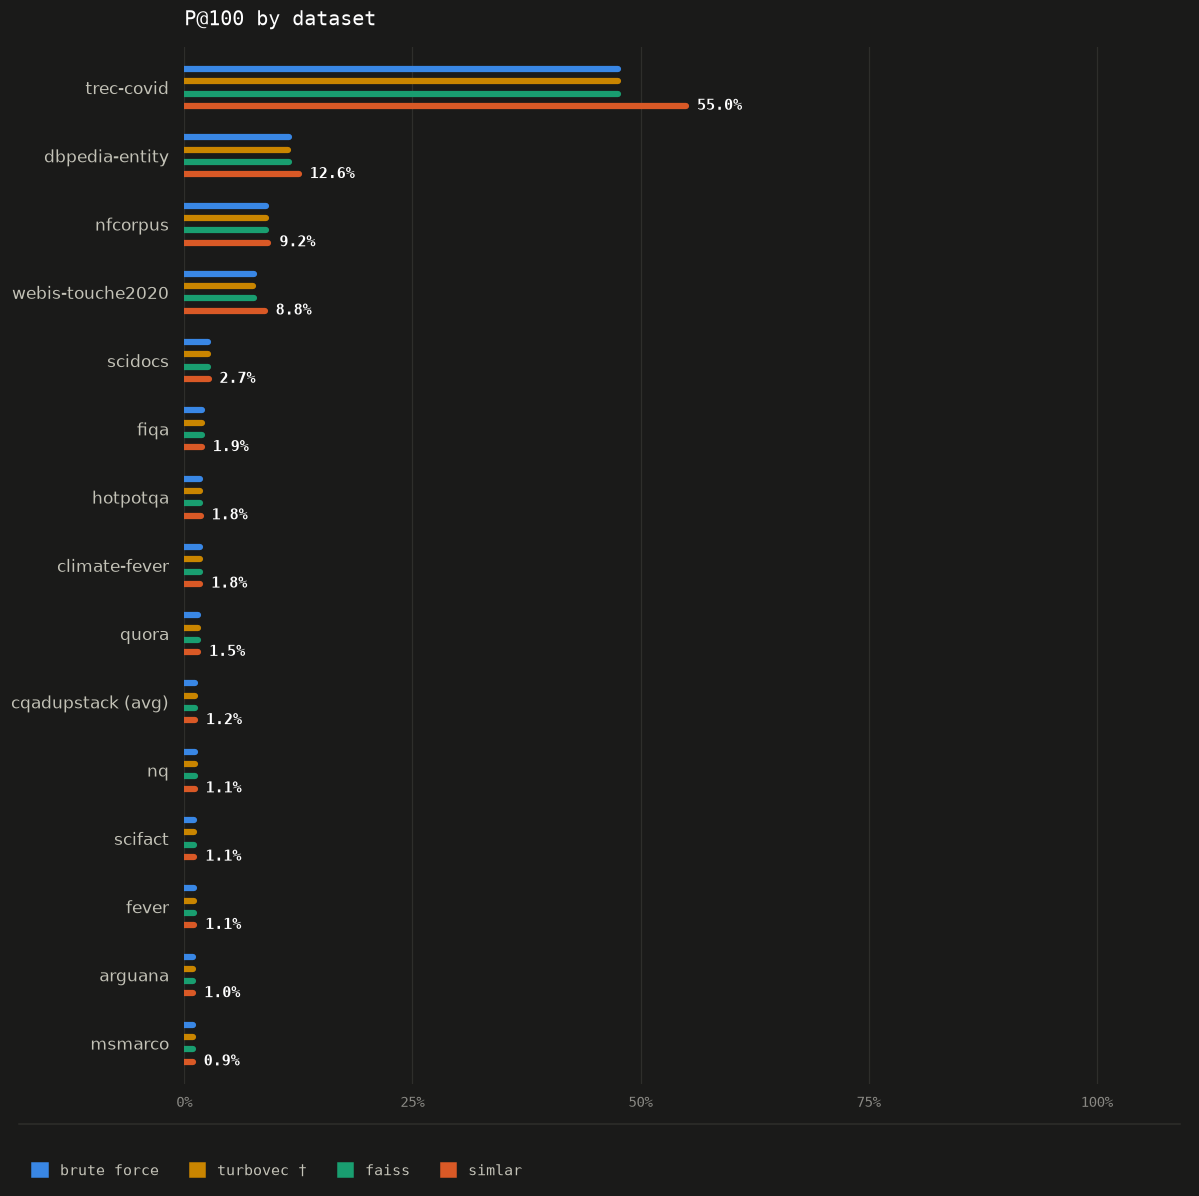

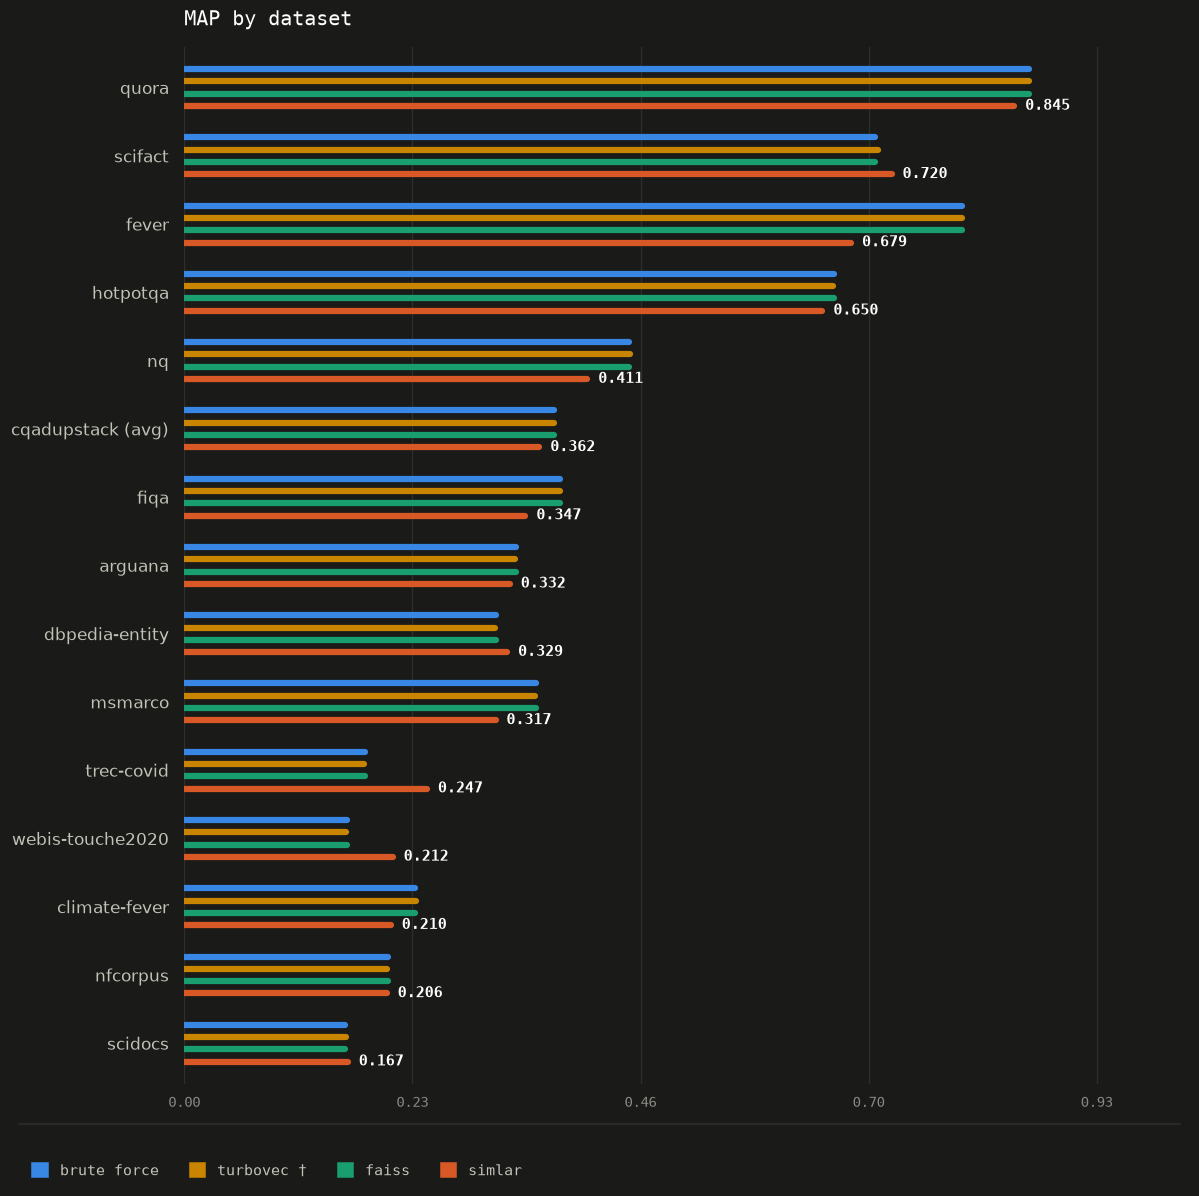

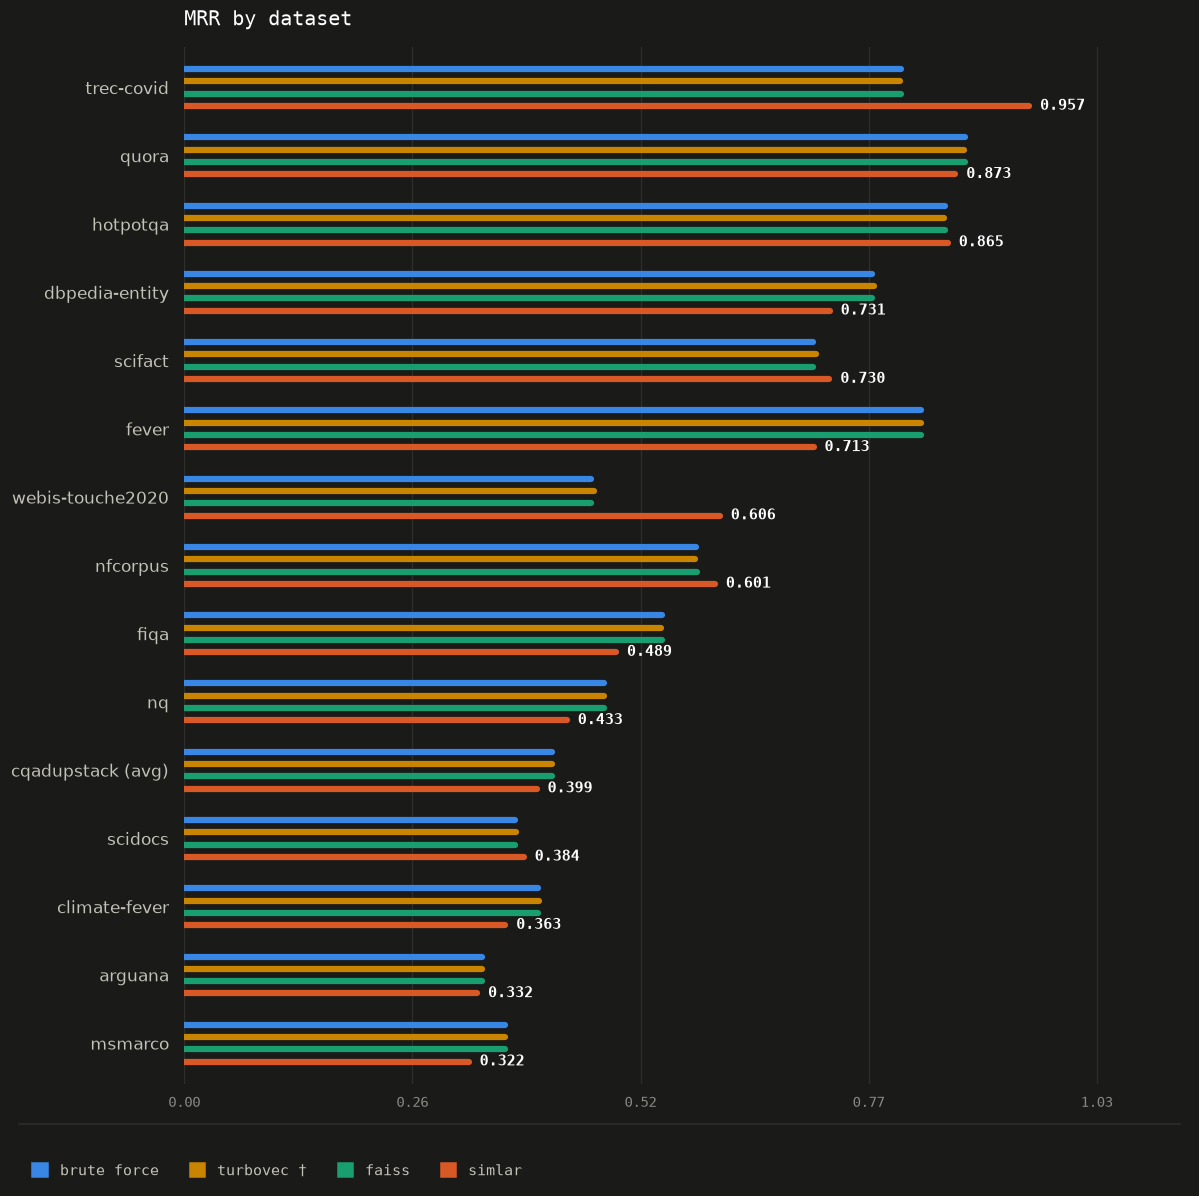

[out] CSVs in /home/aramirez/tekdatum/beir_benchmark/results_notebook, charts in /home/aramirez/tekdatum/beir_benchmark/results_notebook/plots


In [25]:
if ALL:
    for metric in REPORT_METRICS:
        slug = metric.replace("@", "_at_")
        tbl = metric_by_dataset(metric)
        tbl.loc["Average"] = tbl.mean()
        tbl.rename(columns=ENGINE_LABEL).to_csv(os.path.join(OUT_DIR, f"summary_{slug}.csv"))
        plot_metric_by_dataset(metric, save_to=os.path.join(PLOT_DIR, f"{slug}_by_dataset.png"))

    # one row per (dataset, engine): every metric at every K plus timings
    long = pd.DataFrame([
        {"dataset": os.path.basename(result_path(ds))[:-5], "split": p["split"], "engine": m,
         **run["metrics"], **{k: v for k, v in run.items() if k != "metrics"}}
        for ds, p in ALL.items() for m, run in p["runs"].items()
    ])
    long.to_csv(os.path.join(OUT_DIR, "all_results_long.csv"), index=False)
    print(f"[out] CSVs in {os.path.abspath(OUT_DIR)}, charts in {os.path.abspath(PLOT_DIR)}")

## 13. Summary across BEIR
Mean of each metric over the BEIR datasets for each engine, with CQADupStack counted once (its 12-forum average).

In [26]:
if ALL:
    overall = pd.DataFrame({m: metric_by_dataset(m).mean() for m in REPORT_METRICS})
    overall.to_csv(os.path.join(OUT_DIR, "summary_overall.csv"))
    display(HTML(report_table_html(overall, title="BEIR average", row_labels=ENGINE_LABEL,
                                   subtitle=f"{len(metric_by_dataset(REPORT_METRICS[0]))} datasets · model {MODEL}")))

ENGINE,NDCG@100,Recall@100,P@100,MAP,MRR
simlar,53.9%,73.4%,6.8%,0.402,0.587
faiss,54.3%,72.2%,6.1%,0.413,0.589
brute force,54.3%,72.2%,6.1%,0.413,0.589
turbovec †,54.3%,72.2%,6.1%,0.413,0.589
